# Testing and verifying the outputs of various operations

In [2]:
import numpy as np

In [ ]:
arr = np.array([
    [ 1,  2,  3,  4],
    [ 5,  6,  7,  8],
    [ 9, 10, 11, 12],
    [13, 14, 15, 16]
], type)

In [5]:
arr

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16]])

In [ ]:
arr.shape # its 4 x 4

(4, 4)

In [6]:
arr @ arr

array([[ 90, 100, 110, 120],
       [202, 228, 254, 280],
       [314, 356, 398, 440],
       [426, 484, 542, 600]])

In [9]:
arr2 = arr.reshape(-1, 1) # flattened it into a column vector. `-1` is a "whatever works" argument, 1 is what we want the shape to support

In [11]:
arr2.shape # So we asked (*, 1) to be the final shape above basically, and it got resized to match this

(16, 1)

In [12]:
arr3 = arr.reshape(1, -1) # this is asking the data to be reshaped into a shape that matches (1, *)

In [13]:
arr3.shape # So we asked for (1, *) and it got resized to match this (row vector)

(1, 16)

In [14]:
arr4 = arr3.reshape(4, 4) # we are asking to recover the 4 x 4 original shape.

In [ ]:
arr4.shape

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16]])

In [17]:
print(arr)
print()
print(arr4)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]


In [18]:
arr5 = arr4.reshape(4, 4, 1) # the splits must actually make sense, I guess. The flat 1D list of numbers (left to right) must be splittable into equal size arrays

In [ ]:
arr5 # so this is a nested one. Same idea as arr/arr4 but every element is now a vector of size 1 in the middle

array([[[ 1],
        [ 2],
        [ 3],
        [ 4]],

       [[ 5],
        [ 6],
        [ 7],
        [ 8]],

       [[ 9],
        [10],
        [11],
        [12]],

       [[13],
        [14],
        [15],
        [16]]])

In [21]:
arr5.size

16

In [22]:
arr6 = arr5.reshape(-1)
# arr6 = arr5.reshape(16) # aka arr5.size
# arr6 = arr5.flatten()
# arr6 = arr5.ravel()

In [24]:
arr6 # flat 1D vector

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16])

In [25]:
arr6.shape

(16,)

In [ ]:
arr6.reshape(6, -1) # won't work because it can't be split up nicely

ValueError: cannot reshape array of size 16 into shape (6,newaxis)

In [29]:
import numpy as np
from IPython.display import Math, display

def latex_matrix(A, fmt="{:.3g}"):
    rows = [
        " & ".join(fmt.format(x) for x in row)
        for row in A
    ]
    body = r" \\ ".join(rows)
    return r"\begin{bmatrix}" + body + r"\end{bmatrix}"

A = np.random.randn(3, 4)
display(Math(latex_matrix(A)))


<IPython.core.display.Math object>

In [2]:
import torch

a = []

for i in range(10):
    a.append(torch.tensor(i + 0.))

In [3]:
a

[tensor(0.),
 tensor(1.),
 tensor(2.),
 tensor(3.),
 tensor(4.),
 tensor(5.),
 tensor(6.),
 tensor(7.),
 tensor(8.),
 tensor(9.)]

In [4]:
torch.stack(a)

tensor([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [13]:
torch.tensor(a)

tensor([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [3]:
tensor1 = torch.tensor([
    [1., 2., 3., 4.],
    [1., 2., 3., 4.],
    [1., 2., 3., 4.],
])
tensor2 = torch.tensor([
    [5., 6.],
    [5., 6.],
    [5., 6.],
])

concatted = torch.concat([tensor1, tensor2], dim=1)

concatted
# Extends the elements in tensor1 by appending the ones of tensor2 to them

tensor([[1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.]])

Getting them back out...

In [5]:
concatted[:, :4]

tensor([[1., 2., 3., 4.],
        [1., 2., 3., 4.],
        [1., 2., 3., 4.]])

In [7]:
concatted[:, 4:]

tensor([[5., 6.],
        [5., 6.],
        [5., 6.]])

In [11]:
concatted.dtype

torch.float32

In [2]:
import torch
import torch.nn as nn
import sklearn
import torchmetrics

In [16]:
class Dense1(nn.Module):
    def __init__(self, n_features: int, n_neurons: int, n_out: int):
        super().__init__()

        self.linear_regression = nn.Sequential(
            nn.Linear(n_features, n_neurons), nn.ReLU(), # <- single layer
            nn.Linear(n_neurons, n_out) # <- Out layer
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.linear_regression(X)


In [17]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.utils import Bunch

housing: Bunch = fetch_california_housing() # type: ignore

X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data,
    housing.target,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    random_state=42
)

housing: Bunch = fetch_california_housing() # type: ignore

X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data,
    housing.target,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    random_state=42
)

In [18]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)
means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)
# ... normalising it manually instead of using StandardScaler()...
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds

In [19]:
y_train = torch.FloatTensor(y_train).view(-1, 1)
y_valid = torch.FloatTensor(y_valid).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)

In [20]:
X_train.shape[1]

8

In [21]:
y_train.shape[1]

1

In [24]:
from torch.utils.data import DataLoader


def evaluate_tm(model, data_loader: DataLoader, metric: torchmetrics.Metric):
    """
    Evaluate using the torchmetrics library to aggregate the data with a
    standard way of aggregating the error mathematically over all the loops
    """
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():

        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.cuda(), y_batch.cuda()
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration

    return metric.compute()  # compute the final result at the end


def train2(model: nn.Module, optimizer, criterion, metric: torchmetrics.Metric, train_loader: DataLoader, valid_loader: DataLoader, n_epochs: int) -> dict[str, list[float]]:

    history: dict[str, list[float]] = {"train_losses": [], "train_metrics": [], "valid_metrics": []}

    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()

        for X_batch, y_batch in train_loader:
            model.train()

            X_batch, y_batch = X_batch.cuda(), y_batch.cuda()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            total_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            metric.update(y_pred, y_batch)

        mean_loss = total_loss / len(train_loader)

        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(evaluate_tm(model, valid_loader, metric).item())

        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")


    return history

In [25]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=True,
    num_workers=8
)

valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32)

Epoch 1/30, train loss: 1.9129, train metric: 1.3833, valid metric: 2.3636
Epoch 2/30, train loss: 0.7973, train metric: 0.8930, valid metric: 1.4196
Epoch 3/30, train loss: 0.6791, train metric: 0.8241, valid metric: 0.9260
Epoch 4/30, train loss: 0.6409, train metric: 0.8007, valid metric: 0.7935
Epoch 5/30, train loss: 0.6184, train metric: 0.7865, valid metric: 0.7627
Epoch 6/30, train loss: 0.6006, train metric: 0.7751, valid metric: 0.7536
Epoch 7/30, train loss: 0.5855, train metric: 0.7652, valid metric: 0.7450
Epoch 8/30, train loss: 0.5713, train metric: 0.7557, valid metric: 0.7469
Epoch 9/30, train loss: 0.5584, train metric: 0.7474, valid metric: 0.7303
Epoch 10/30, train loss: 0.5465, train metric: 0.7392, valid metric: 0.7184
Epoch 11/30, train loss: 0.5354, train metric: 0.7316, valid metric: 0.7101
Epoch 12/30, train loss: 0.5254, train metric: 0.7249, valid metric: 0.7042
Epoch 13/30, train loss: 0.5157, train metric: 0.7183, valid metric: 0.7028
Epoch 14/30, train lo

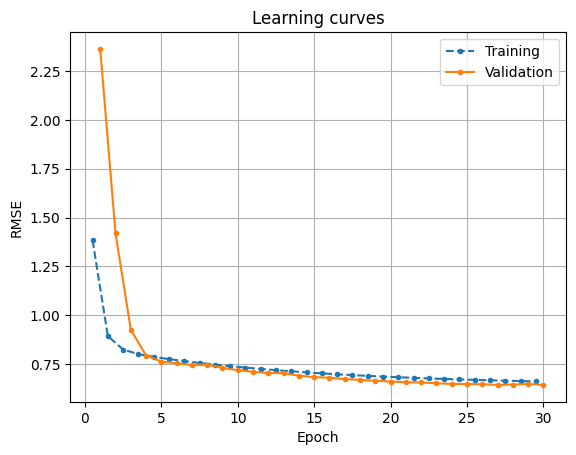

In [32]:
import matplotlib.pyplot as plt
import numpy as np

learning_rate = 0.0005
n_epochs = 30

torch.manual_seed(42)

model = Dense1(X_train.shape[1], 100, y_train.shape[1]).cuda()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss().cuda()
rmse = torchmetrics.MeanSquaredError(squared=False).cuda()

history = train2(
    model=model,
    optimizer=optimizer,
    criterion=mse,
    metric=rmse,
    train_loader=train_loader,
    valid_loader=valid_loader,
    n_epochs=n_epochs
)

plt.plot(
    np.arange(n_epochs) + 0.5,
    history["train_metrics"],
    ".--",
    label="Training"
)
plt.plot(
    np.arange(n_epochs) + 1.0,
    history["valid_metrics"],
    ".-",
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.grid()
plt.title("Learning curves")
#plt.axis([0.5, float(n_epochs), 0.4, 1.0])
plt.legend()
plt.show()

In [38]:
model.eval()

X_test_some = X_test[:10].cuda()
with torch.no_grad():
    y_pred_some = model(X_test_some)

y_pred_some

tensor([[0.5126],
        [1.5890],
        [3.2116],
        [2.6393],
        [2.6170],
        [2.0346],
        [2.5813],
        [1.8351],
        [2.8437],
        [4.0333]], device='cuda:0')

In [39]:
y_test[:10]

tensor([[0.4770],
        [0.4580],
        [5.0000],
        [2.1860],
        [2.7800],
        [1.5870],
        [1.9820],
        [1.5750],
        [3.4000],
        [4.4660]])

Custom Dense using `nn.Parameter`:

In [3]:
class CustomDense1(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()

        self.linear = nn.Linear(in_features, out_features)
        self.relu = nn.ReLU()

    def forward(self, X):
        return self.relu(self.linear(X))

In [5]:
torch.manual_seed(42)

dense = CustomDense1(3, 5)
X = torch.randn(2, 3)
X

tensor([[ 0.5349,  0.8094,  1.1103],
        [-1.6898, -0.9890,  0.9580]])

In [8]:
y_pred = dense(X) # <- got randomly initialised
y_pred.shape

torch.Size([2, 5])

In [10]:
# manual linear computation:
y_pred_check = torch.relu(X @ dense.linear.weight.T + dense.linear.bias)

# verifying that both results are equal (with some builtin tolerance)
torch.allclose(y_pred, y_pred_check)

True

In [13]:
torch.randn(2, 3)

tensor([[-0.0499,  0.5263, -0.0085],
        [ 0.7291,  0.1331,  0.8640]])

In [26]:
import torch.nn.functional as F

class CustomDenseUsingParameter(nn.Module):
    def __init__(self, in_features: int, out_features: int) -> None:
        super().__init__()

        self.weights = nn.Parameter(torch.randn(out_features, in_features))
        #nn.init.kaiming_uniform_(self.weights, nonlinearity="relu")
        self.bias = nn.Parameter(torch.zeros(out_features))


    def forward(self, X: torch.Tensor):
        z = X @ self.weights.T + self.bias
        return F.relu(z)

In [27]:
torch.manual_seed(42)

dense = CustomDenseUsingParameter(3, 5)
X = torch.randn(2, 3)
X

tensor([[ 0.9580,  1.3221,  0.8172],
        [-0.7658, -0.7506,  1.3525]])

In [28]:
y_pred = dense(X) # <- got randomly initialised
y_pred.shape

torch.Size([2, 5])

In [29]:
y_pred_check = F.relu(X @ dense.weights.T + dense.bias)
torch.allclose(y_pred, y_pred_check)

True